# Phần 2: Phân tích Mô tả & Chẩn đoán (Descriptive & Diagnostic Analysis)
**Người thực hiện:** Võ Việt Hoàng (MSSV 52400191)

Notebook này trả lời các câu hỏi phân tích mô tả và chẩn đoán được nêu trong README, nhằm xác định **điểm đen (hotspot)**, **khung giờ nguy hiểm**, và các yếu tố liên quan đến mức độ nghiêm trọng của tai nạn, phục vụ đề xuất giải pháp trước mùa mưa bão.

## 0. Import thư viện

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
from scipy import stats as sst


## 1. Đọc và kiểm tra dữ liệu
Đọc dữ liệu tai nạn đã được làm sạch từ bước `01_data_cleaning.ipynb`.

In [2]:
# Đường dẫn tương đối trỏ tới file clean
file_path = '../data/accidents_clean_2y.csv'

# Đọc file csv thành DataFrame
df = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên để kiểm tra dữ liệu đã load thành công chưa
df.head()

,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,City,County,State,Zipcode,...,Month,Year,Season,Is_Daytime,Is_Precipitation,Weather_Group,Visibility_Level,Temp_Level,Is_Adverse_Weather,Is_Low_Visibility
0,A-5728132,2,2021-03-31 23:37:00,2021-04-01 04:55:18,33.498878,-117.152747,Temecula,Riverside,CA,92590-1809,...,3,2021,Spring,False,False,Clear,High,Mild,False,False
1,A-6223262,2,2021-03-31 23:37:00,2021-04-01 04:05:36,33.498688,-117.153094,Temecula,Riverside,CA,92590-1809,...,3,2021,Spring,False,False,Clear,High,Mild,False,False
2,A-5711549,2,2021-03-31 23:37:30,2021-04-01 12:10:30,33.968597,-117.328554,Riverside,Riverside,CA,92521,...,3,2021,Spring,False,False,Clear,High,Mild,False,False
3,A-5476787,2,2021-03-31 23:37:30,2021-04-01 10:26:56,33.975521,-117.335277,Riverside,Riverside,CA,92507,...,3,2021,Spring,False,False,Clear,High,Mild,False,False
4,A-6178868,2,2021-03-31 23:37:30,2021-04-01 10:49:00,34.028558,-117.331037,Colton,San Bernardino,CA,92324,...,3,2021,Spring,False,False,Clear,High,Mild,False,False


In [3]:
df.shape


(2972890, 36)

In [4]:
df.columns

Index(['ID', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng',
       'City', 'County', 'State', 'Zipcode', 'Temperature(F)', 'Humidity(%)',
       'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Crossing',
       'Junction', 'Railway', 'Stop', 'Traffic_Signal', 'Sunrise_Sunset',
       'Hour', 'DayOfWeek', 'Month', 'Year', 'Season', 'Is_Daytime',
       'Is_Precipitation', 'Weather_Group', 'Visibility_Level', 'Temp_Level',
       'Is_Adverse_Weather', 'Is_Low_Visibility'],
      dtype='object')

**Nhận xét:** Bộ dữ liệu có **2,972,890 bản ghi** trải dài khoảng 2 năm (từ 31/03/2021 đến khoảng tháng 3/2023), gồm 36 cột bao gồm thời gian, vị trí, thời tiết và các đặc điểm hạ tầng tại nơi xảy ra tai nạn — đủ điều kiện để phân tích cả về không gian, thời gian lẫn nguyên nhân.

## 2. Câu hỏi 1 — Khu vực/thành phố nào có mật độ tai nạn cao nhất? (Điểm đen theo City)
Kết hợp 2 chỉ số trên cùng biểu đồ: **tổng số vụ** và **tỷ lệ tai nạn nghiêm trọng (Severity ≥ 3)**, để tránh chỉ nhìn số lượng thô mà bỏ qua mức độ nguy hiểm thực sự.

             Total_Accidents  Severe_Count  Severe_Rate_%
City                                                     
Miami                 112899          2188           1.94
Orlando                65531           847           1.29
Los Angeles            57077          4539           7.95
Houston                48500          4809           9.92
Dallas                 48154          5821          12.09
Charlotte              44914          1589           3.54
Raleigh                30195           903           2.99
Nashville              28111          1538           5.47
Baton Rouge            25540           981           3.84
San Diego              24009          1035           4.31


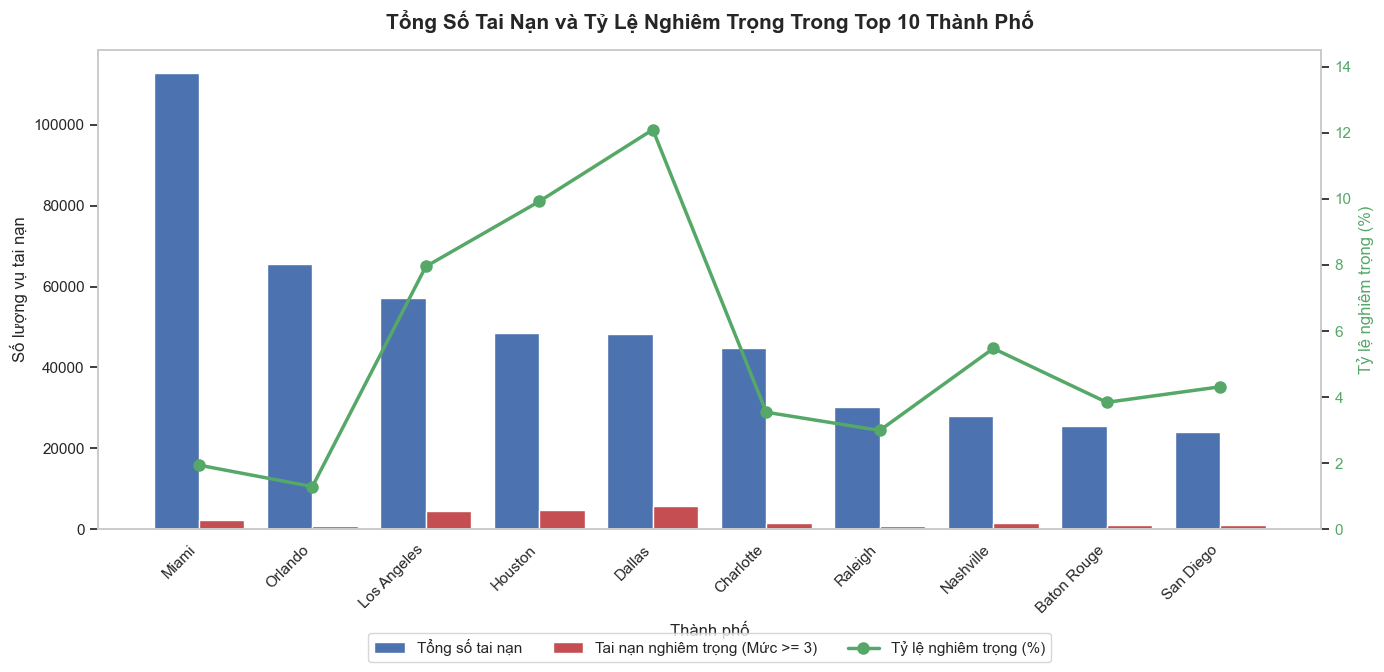

In [77]:
city_stats = df.groupby('City').agg(
    Total_Accidents=('ID', 'count'),
    Severe_Count=('Severity', lambda x: (x >= 3).sum())
)
city_stats['Severe_Rate_%'] = (city_stats['Severe_Count'] / city_stats['Total_Accidents'] * 100).round(2)
top10_city = city_stats.sort_values('Total_Accidents', ascending=False).head(10)
print(top10_city)


fig, ax1 = plt.subplots(figsize=(14, 7))

# Lấy danh sách thành phố và thiết lập vị trí các cột
cities = top10_city.index
x = np.arange(len(cities))
width = 0.4 # Độ rộng của mỗi cột

# 1. Trục chính (Bên trái): Vẽ 2 cột Tổng số và Số ca nghiêm trọng
ax1.bar(x - width/2, top10_city['Total_Accidents'], width, label='Tổng số tai nạn', color='#4C72B0')
ax1.bar(x + width/2, top10_city['Severe_Count'], width, label='Tai nạn nghiêm trọng (Mức >= 3)', color='#C44E52')

ax1.set_xticks(x)
ax1.set_xticklabels(cities, rotation=45, ha='right', fontsize=11)
ax1.set_ylabel('Số lượng vụ tai nạn', fontsize=12)
ax1.set_xlabel('Thành phố', fontsize=12)

# 2. Trục phụ (Bên phải): Vẽ đường Tỷ lệ phần trăm (%)
ax2 = ax1.twinx() # Lệnh này tạo trục Y thứ 2 dùng chung trục X với ax1
ax2.plot(x, top10_city['Severe_Rate_%'], color='#55A868', marker='o', linewidth=2.5, markersize=8, label='Tỷ lệ nghiêm trọng (%)')

ax2.set_ylabel('Tỷ lệ nghiêm trọng (%)', color='#55A868', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#55A868')
ax2.set_ylim(0, max(top10_city['Severe_Rate_%']) * 1.2) # Mở rộng đỉnh trục Y một chút cho thoáng

# 3. Tiêu đề và Chú giải (Legend)
plt.title('Tổng Số Tai Nạn và Tỷ Lệ Nghiêm Trọng Trong Top 10 Thành Phố', fontsize=15, fontweight='bold', pad=15)

# Gom chú giải của cả 2 trục về cùng một khung đặt ở dưới cùng
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, fontsize=11)

# Căn chỉnh để không bị lẹm chữ và hiển thị
ax1.grid(False) 
ax2.grid(False)
plt.tight_layout()
plt.show()

**Nhận xét:** Miami dẫn đầu tuyệt đối về **tổng số vụ** (112,899 vụ) nhưng chỉ có **1.94%** là nghiêm trọng — thấp nhất trong top 10. Ngược lại, Dallas tuy tổng số vụ thấp hơn nhiều (48,154 vụ) nhưng lại có **tỷ lệ nghiêm trọng cao nhất (12.09%)**, theo sau là Houston (9.92%). Điều này cho thấy "nhiều tai nạn nhất" và "nguy hiểm nhất" là hai khái niệm khác nhau, cần xử lý bằng chiến lược khác nhau (Miami cần giảm tần suất, Dallas/Houston cần giảm mức độ nghiêm trọng).

## 3. Câu hỏi 2 — Khung giờ nào trong ngày xảy ra tai nạn nhiều nhất?

Hour
16    252396
17    242691
15    240720
7     202977
14    200878
8     187204
18    168923
13    162967
6     145789
12    144325
dtype: int64


C:\Users\Zen12\AppData\Local\Temp\ipykernel_1308\410815691.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


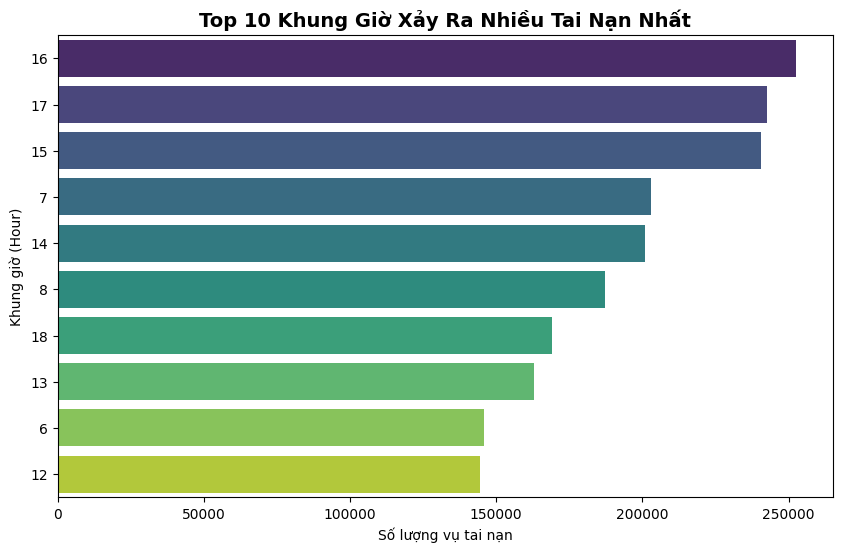

In [6]:
# 1. Gom nhóm và lấy top 10
hour_per_accident = df.groupby('Hour').size().sort_values(ascending=False).head(10)
print(hour_per_accident)

# 2. Tạo khung hình
plt.figure(figsize=(10, 6))

# 3. Vẽ biểu đồ thanh ngang bằng seaborn (lưu ý ép kiểu index thành string để biểu đồ không bị dính chữ)
sns.barplot(
    x=hour_per_accident.values, 
    y=hour_per_accident.index.astype(str), 
    palette="viridis"
)

# 4. Thêm tiêu đề cho rõ ràng
plt.title('Top 10 Khung Giờ Xảy Ra Nhiều Tai Nạn Nhất', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng vụ tai nạn')
plt.ylabel('Khung giờ (Hour)')

plt.show()

**Nhận xét:** Khung giờ 15h-18h (giờ tan tầm buổi chiều) chiếm ưu thế rõ rệt, với 16h dẫn đầu (252,396 vụ). Khung giờ 6h-8h (giờ đi làm buổi sáng) cũng nằm trong top 10 nhưng thấp hơn đáng kể so với buổi chiều, cho thấy mật độ giao thông buổi chiều cùng với ánh sáng yếu dần có thể là yếu tố góp phần làm tăng nguy cơ tai nạn.

## 4. Câu hỏi 3 — Ngày nào trong tuần có tỷ lệ tai nạn cao nhất?

           Total_Accident  Day_Rate_(%)  Night_Rate_(%)
DayOfWeek                                              
Monday             428231         72.21           27.79
Tuesday            467599         73.48           26.52
Wednesday          486922         73.45           26.55
Thursday           492193         73.00           27.00
Friday             523571         72.03           27.97
Saturday           317848         64.45           35.55
Sunday             256526         61.02           38.98


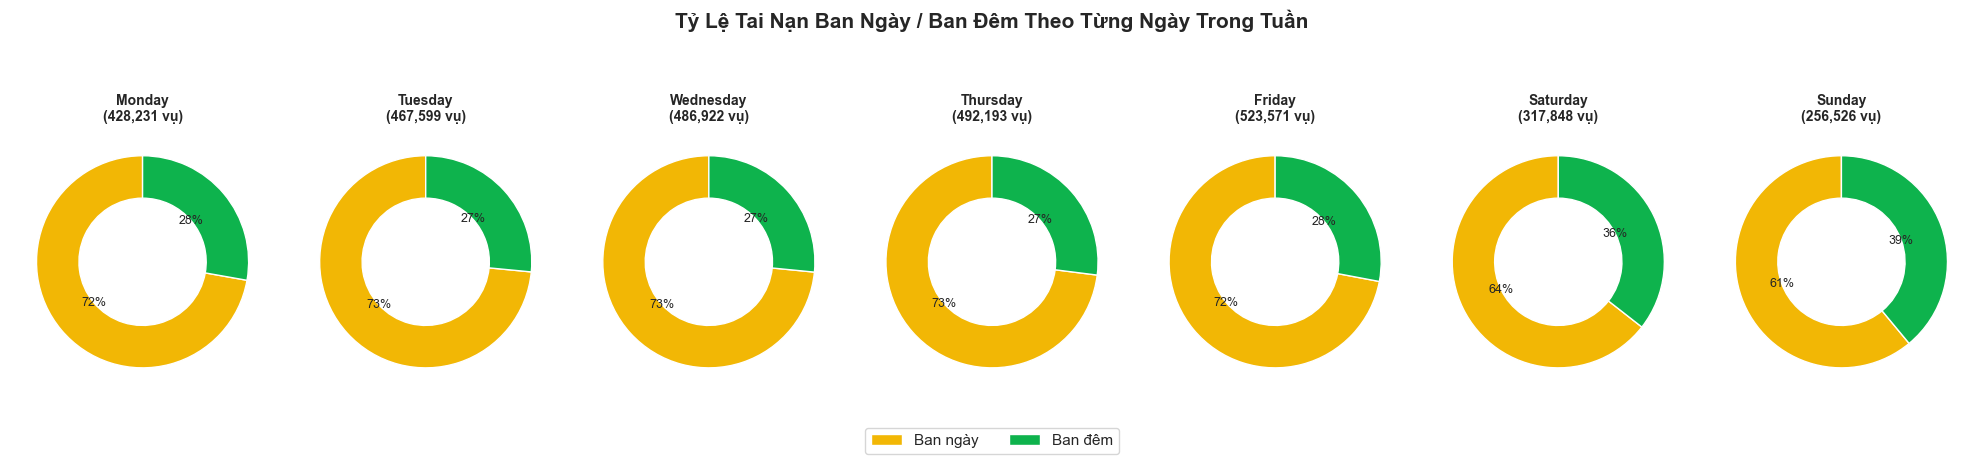

In [ ]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_accident_rate = df.groupby('DayOfWeek').agg(
    Total_Accident=('ID', 'count'),
    Day_Count=('Is_Daytime', 'sum')
).reindex(day_order)  

day_accident_rate['Night_Count'] = day_accident_rate['Total_Accident'] - day_accident_rate['Day_Count']
day_accident_rate['Day_Rate_(%)'] = (day_accident_rate['Day_Count'] / day_accident_rate['Total_Accident'] * 100).round(2)
day_accident_rate['Night_Rate_(%)'] = (day_accident_rate['Night_Count'] / day_accident_rate['Total_Accident'] * 100).round(2)
print(day_accident_rate[['Total_Accident', 'Day_Rate_(%)', 'Night_Rate_(%)']])

fig, axes = plt.subplots(1, 7, figsize=(20, 4))
colors = ['#F2B705', "#0EB34D"]

for i, day in enumerate(day_order):
    ax = axes[i]
    sizes = [day_accident_rate.loc[day, 'Day_Rate_(%)'], day_accident_rate.loc[day, 'Night_Rate_(%)']]
    ax.pie(sizes, colors=colors, autopct='%1.0f%%', startangle=90,
           wedgeprops=dict(width=0.4, edgecolor='white'), textprops={'fontsize': 9})
    total = int(day_accident_rate.loc[day, 'Total_Accident'])
    ax.set_title(f'{day}\n({total:,} vụ)', fontsize=10, fontweight='bold')

fig.suptitle('Tỷ Lệ Tai Nạn Ban Ngày / Ban Đêm Theo Từng Ngày Trong Tuần', fontsize=15, fontweight='bold', y=1.08)
fig.legend(['Ban ngày', 'Ban đêm'], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05), fontsize=11)
plt.tight_layout(); plt.show()

**Nhận xét:** Thứ Sáu có tổng số vụ cao nhất (523,571 vụ, chiếm 17.61% tuần), và các ngày trong tuần làm việc (Thứ Hai - Thứ Sáu) đều có tỷ lệ tai nạn ban ngày cao hơn hẳn (72-73%) so với cuối tuần (Thứ Bảy 64.45%, Chủ Nhật chỉ 61.02%). Điều này phù hợp với giả thuyết tai nạn ngày thường gắn liền với giờ đi làm/tan tầm, còn cuối tuần tai nạn có xu hướng dịch chuyển sang ban đêm nhiều hơn.

## 5. Câu hỏi 4 — Tháng nào trong năm ghi nhận nhiều tai nạn nhất?

=== Độ phủ dữ liệu theo tháng ===
                  Days_With_Data   Total  Days_In_Month  Coverage_%
YearMonth_Period                                                   
2021-03                        1      13             31         3.2
2023-03                       17   27783             31        54.8
2022-10                       21   79326             31        67.7
2022-11                       27  122488             30        90.0
2023-02                       26   51570             28        92.9
2021-10                       29  127311             31        93.5
2022-03                       30  131280             31        96.8
2023-01                       30  150445             31        96.8
2022-05                       30  150505             31        96.8
2022-12                       31  176318             31       100.0
2022-09                       30  129963             30       100.0
2022-08                       31  141525             31       100.0
2022-07       

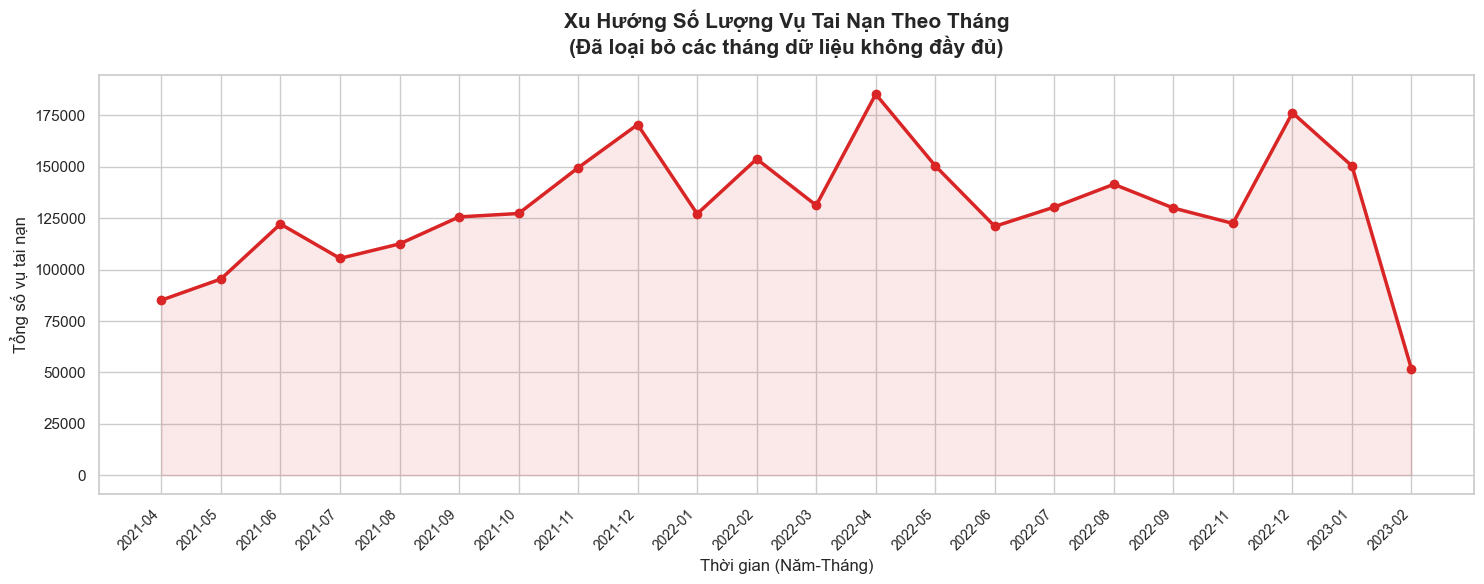

In [73]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'])
df['YearMonth_Period'] = df['Start_Time'].dt.to_period('M')

# Bước 1: Kiểm tra độ phủ dữ liệu (Coverage) của từng tháng
monthly_coverage = df.groupby('YearMonth_Period')['Start_Time'].agg(
    Days_With_Data=lambda s: s.dt.date.nunique(),
    Total='size'
)
monthly_coverage['Days_In_Month'] = monthly_coverage.index.days_in_month
monthly_coverage['Coverage_%'] = (monthly_coverage['Days_With_Data'] / monthly_coverage['Days_In_Month'] * 100).round(1)
print("=== Độ phủ dữ liệu theo tháng ===")
print(monthly_coverage.sort_values('Coverage_%',ascending=True))

# Bước 2: Loại bỏ các tháng có độ phủ quá thấp (dữ liệu bị cụt)
COVERAGE_THRESHOLD = 90
excluded = monthly_coverage[monthly_coverage['Coverage_%'] < COVERAGE_THRESHOLD]
full_months = monthly_coverage[monthly_coverage['Coverage_%'] >= COVERAGE_THRESHOLD].index
print(f"\n=== Các tháng bị loại vì độ phủ < {COVERAGE_THRESHOLD}% ===")
print(excluded)

df_full_months = df[df['YearMonth_Period'].isin(full_months)]

# Bước 3: Vẽ lại xu hướng chỉ trên các tháng đầy đủ
accidents_through_month = df_full_months.groupby('YearMonth_Period').size().sort_index()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))
plt.plot(accidents_through_month.index.astype(str), accidents_through_month.values,
         marker='o', linestyle='-', color='#D92525', linewidth=2.5, markersize=6)
plt.fill_between(accidents_through_month.index.astype(str), accidents_through_month.values,
                  color='#D92525', alpha=0.1)
plt.title('Xu Hướng Số Lượng Vụ Tai Nạn Theo Tháng\n(Đã loại bỏ các tháng dữ liệu không đầy đủ)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Thời gian (Năm-Tháng)'); plt.ylabel('Tổng số vụ tai nạn')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout(); plt.show()

**Nhận xét:** Số vụ tai nạn có xu hướng tăng vào các tháng cuối năm (tháng 11-12 của cả 2 năm đều thuộc nhóm cao nhất, ví dụ 12/2021: 170,578 vụ và 12/2022: 176,318 vụ), trùng với giai đoạn thời tiết xấu/mùa lễ cuối năm tại Mỹ.
(**Thông tin thêm:** Tháng 2 năm 2023 ở Mỹ đã có đợt bão tuyết khổng lồ làm ảnh hưởng tới các Bang có mật độ giao thông cao như California, Texas,... khiến dữ liệu có sự biến động)

## 6. Câu hỏi 5  — Mức độ nghiêm trọng có thay đổi theo điều kiện thời tiết không?

Severity            Severity1  Severity2  Severity3  Severity4  SeverityTotal
Is_Adverse_Weather                                                           
False                   33597    2332673     155021      56839        2578130
True                     2528     358902      24349       8981         394760
Total                   36125    2691575     179370      65820        2972890
Severity                   1          2         3         4
Is_Adverse_Weather                                         
False               1.303154  90.479262  6.012924  2.204660
True                0.640389  90.916506  6.168051  2.275053


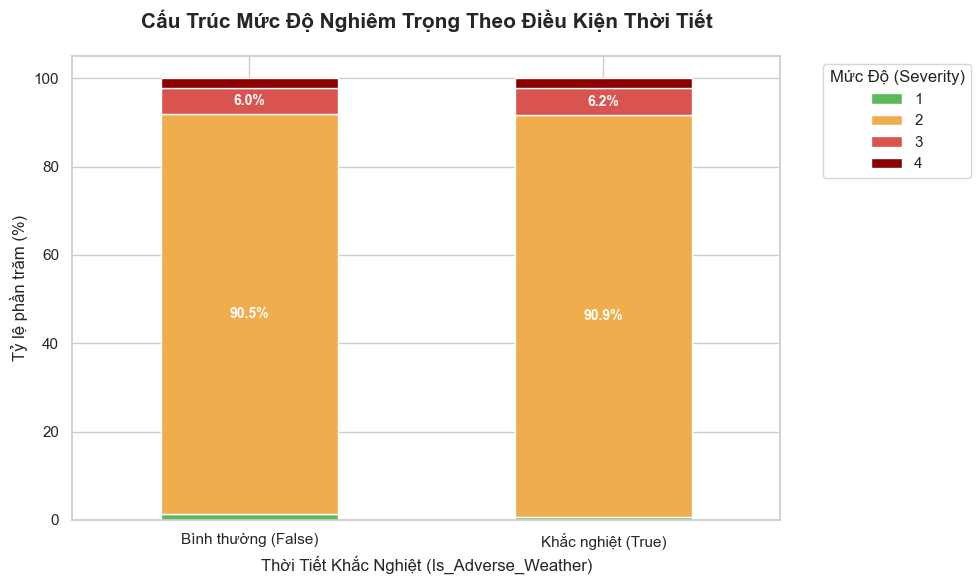

In [ ]:
severity_base_wc = pd.crosstab(df['Is_Adverse_Weather'], df['Severity'],margins=True,margins_name="Total") 
severity_base_wc = severity_base_wc.add_prefix('Severity')

print(severity_base_wc)

severity_pct = pd.crosstab(df['Is_Adverse_Weather'], df['Severity'], normalize='index') * 100
print(severity_pct)


colors = ['#5CB85C', '#F0AD4E', '#D9534F', '#8B0000']

ax = severity_pct.plot(
    kind='bar', 
    stacked=True, 
    figsize=(10, 6), 
    color=colors, 
    edgecolor='white' 
)

plt.title('Cấu Trúc Mức Độ Nghiêm Trọng Theo Điều Kiện Thời Tiết', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Thời Tiết Khắc Nghiệt (Is_Adverse_Weather)', fontsize=12)
plt.ylabel('Tỷ lệ phần trăm (%)', fontsize=12)

plt.xticks(ticks=[0, 1], labels=['Bình thường (False)', 'Khắc nghiệt (True)'], rotation=0, fontsize=11)

plt.legend(title='Mức Độ (Severity)', bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5:
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

**Nhận xét:** Khác với giả định ban đầu, sự khác biệt về tỷ lệ tai nạn nghiêm trọng giữa điều kiện thời tiết khắc nghiệt và bình thường là **không lớn**: nhóm thời tiết khắc nghiệt có 6.17% Severity 3 và 2.28% Severity 4, so với 6.01% và 2.20% ở nhóm bình thường — chênh lệch dưới 0.2 điểm phần trăm. Điều này gợi ý rằng thời tiết xấu tuy làm *tăng tần suất* tai nạn nhưng không nhất thiết làm *tăng đáng kể mức độ* nghiêm trọng trong bộ dữ liệu này — một phát hiện đáng lưu ý, cần đối chiếu thêm với yếu tố hạ tầng/tốc độ thay vì kết luận vội rằng thời tiết là nguyên nhân chính gây tai nạn nặng.

## 7. Câu hỏi 6  — Những điều kiện hạ tầng nào liên quan đến tai nạn nghiêm trọng nhất?
Phân tích ma trận đồng xuất hiện (co-occurrence) giữa các loại hạ tầng, chỉ tính trên các vụ tai nạn mức độ nghiêm trọng nhất (Severity = 4), để xem mỗi loại hạ tầng thường gây tai nạn độc lập hay kết hợp với hạ tầng khác.

Đang phân tích Severity = 4
Số vụ tai nạn nghiêm trọng: 65,820 / Tổng: 2,972,890

=== Ma trận đồng xuất hiện ===
                Amenity  Crossing  Junction  Railway  Stop  Traffic_Signal
Amenity             200       229         6       31    45             210
Crossing            229       821        53      448   284            2040
Junction              6        53      5048       14    21              43
Railway              31       448        14       40    26             108
Stop                 45       284        21       26  1679              74
Traffic_Signal      210      2040        43      108    74            3514

=== Kiểm tra đối chiếu ===
Amenity: Tổng thực tế=524, Đứng độc lập=200
Crossing: Tổng thực tế=3505, Đứng độc lập=821
Junction: Tổng thực tế=5151, Đứng độc lập=5048
Railway: Tổng thực tế=503, Đứng độc lập=40
Stop: Tổng thực tế=2031, Đứng độc lập=1679
Traffic_Signal: Tổng thực tế=5691, Đứng độc lập=3514


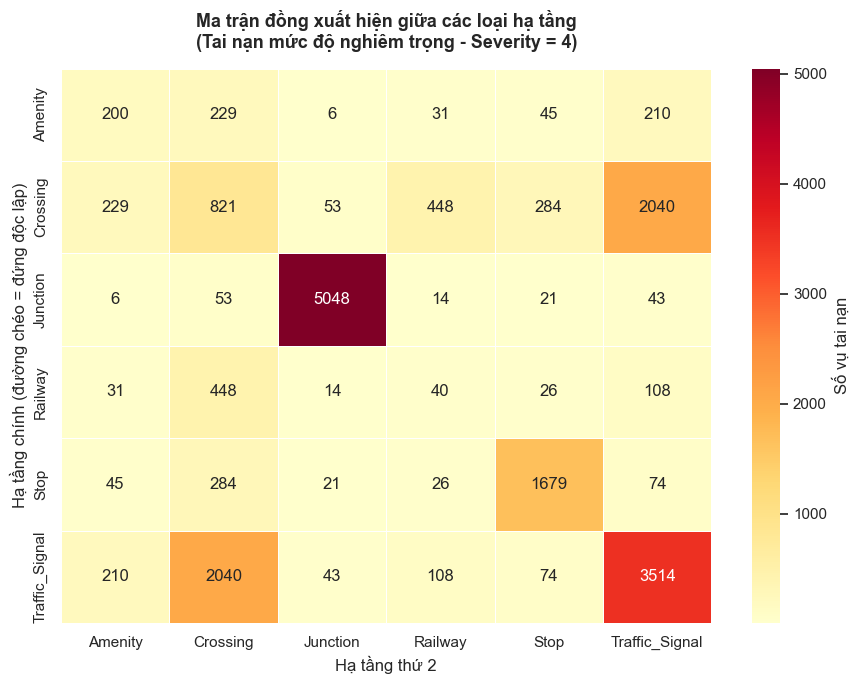

In [45]:
df_severe = df[df['Severity'] == 4].copy()

print(f"Đang phân tích Severity = 4")
print(f"Số vụ tai nạn nghiêm trọng: {len(df_severe):,} / Tổng: {len(df):,}")


infra_cols = ['Amenity', 'Crossing', 'Junction', 'Railway', 'Stop', 'Traffic_Signal']

for col in infra_cols:
    if df_severe[col].dtype != bool:
        df_severe[col] = df_severe[col].astype(bool)




matrix = pd.DataFrame(0, index=infra_cols, columns=infra_cols)

for i in infra_cols:
    for j in infra_cols:
        if i == j:
            other_cols = [c for c in infra_cols if c != i]
            mask = (df_severe[i] == True) & (df_severe[other_cols].sum(axis=1) == 0)
            matrix.loc[i, j] = mask.sum()
        else:
            mask = (df_severe[i] == True) & (df_severe[j] == True)
            matrix.loc[i, j] = mask.sum()

print("\n=== Ma trận đồng xuất hiện ===")
print(matrix)


print("\n=== Kiểm tra đối chiếu ===")
for infra in infra_cols:
    tong_thuc_te = len(df_severe[df_severe[infra] == True])
    doc_lap = matrix.loc[infra, infra]
    print(f"{infra}: Tổng thực tế={tong_thuc_te}, Đứng độc lập={doc_lap}")

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    matrix,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Số vụ tai nạn'},
    ax=ax
)

ax.set_title(f'Ma trận đồng xuất hiện giữa các loại hạ tầng\n'
             f'(Tai nạn mức độ nghiêm trọng - Severity = 4)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Hạ tầng thứ 2')
ax.set_ylabel('Hạ tầng chính (đường chéo = đứng độc lập)')

plt.tight_layout()
plt.show()

**Nhận xét:** Junction (giao lộ) có tới **5,048/5,151 vụ (98%) xảy ra độc lập**, không đi kèm hạ tầng nào khác — cho thấy bản thân cấu trúc giao lộ là yếu tố rủi ro chính, không phụ thuộc đèn tín hiệu hay biển báo đi kèm. Ngược lại, Crossing chỉ có 821/3,505 vụ (23%) độc lập, phần lớn còn lại kết hợp với Traffic_Signal (2,040 vụ) — cho thấy các điểm băng qua đường có đèn tín hiệu vẫn tiềm ẩn nguy cơ cao, gợi ý cần rà soát lại hiệu quả thực tế của đèn tín hiệu tại các điểm Crossing thay vì chỉ dựa vào việc đã lắp đặt hay chưa.

## 8. Câu hỏi 8 — Top điểm đen cần ưu tiên can thiệp trước mùa mưa bão
Tổng hợp 3 yếu tố (tổng số vụ, tỷ lệ nghiêm trọng, tỷ lệ liên quan thời tiết xấu) thành một **điểm ưu tiên (Priority Score)** có trọng số, để xếp hạng các khu vực cần can thiệp trước mùa mưa bão.

=== DANH SÁCH 1: TOP HOTSPOT THEO KHỐI LƯỢNG ===
                     Location_Key  Total_Accidents  Severe_Rate_%  Weather_Related_Rate_%
            Miami, Miami-Dade, FL           112839           1.94                   11.55
              Orlando, Orange, FL            65505           1.29                   10.92
     Los Angeles, Los Angeles, CA            57077           7.95                    8.04
              Houston, Harris, TX            48286           9.96                   10.18
               Dallas, Dallas, TX            47166          12.27                    8.36
       Charlotte, Mecklenburg, NC            44790           3.48                    9.11
                Raleigh, Wake, NC            30176           2.99                    8.79
          Nashville, Davidson, TN            27962           5.37                   11.15
Baton Rouge, East Baton Rouge, LA            25540           3.84                   14.04
         San Diego, San Diego, CA            24009 

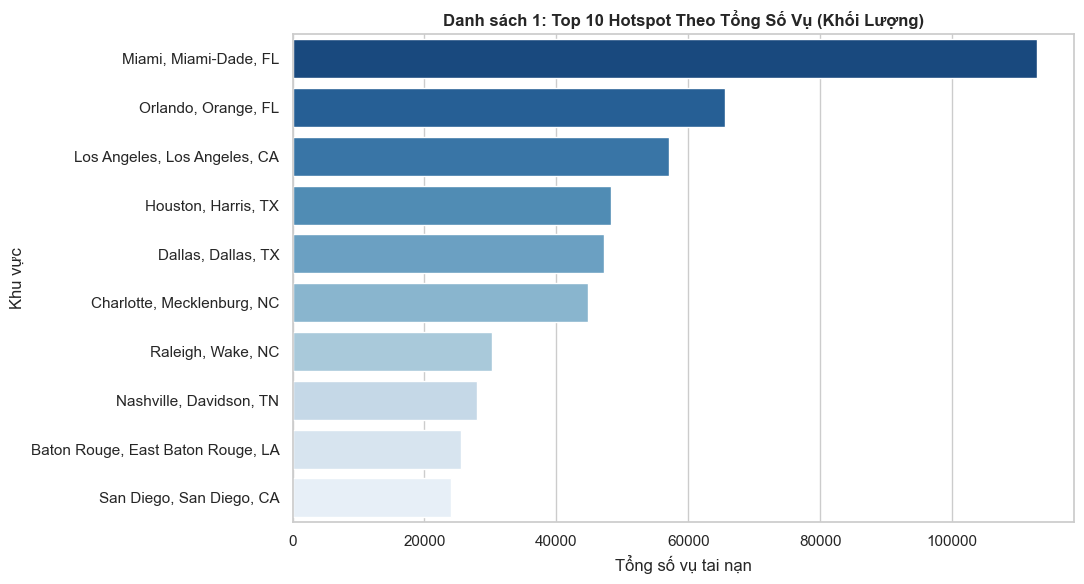


=== DANH SÁCH 2: TOP TỶ LỆ NGHIÊM TRỌNG (đã điều chỉnh cỡ mẫu) ===
                Location_Key  Total_Accidents  Severe_Rate_%  Wilson_Severe_Rate_%
   Springfield, Sangamon, IL              120          94.17                 88.45
          Lincoln, Logan, IL               41          97.56                 87.40
    Champaign, Champaign, IL               92          93.48                 86.49
   Caseyville, St. Clair, IL               43          95.35                 84.54
       Urbana, Champaign, IL               40          95.00                 83.50
    Effingham, Effingham, IL               47          93.62                 82.84
          Normal, McLean, IL               36          91.67                 78.17
      Marion, Williamson, IL               36          91.67                 78.17
   Bourbonnais, Kankakee, IL               42          90.48                 77.93
        Benton, Franklin, IL               30          90.00                 74.38
  Litchfield, Montg

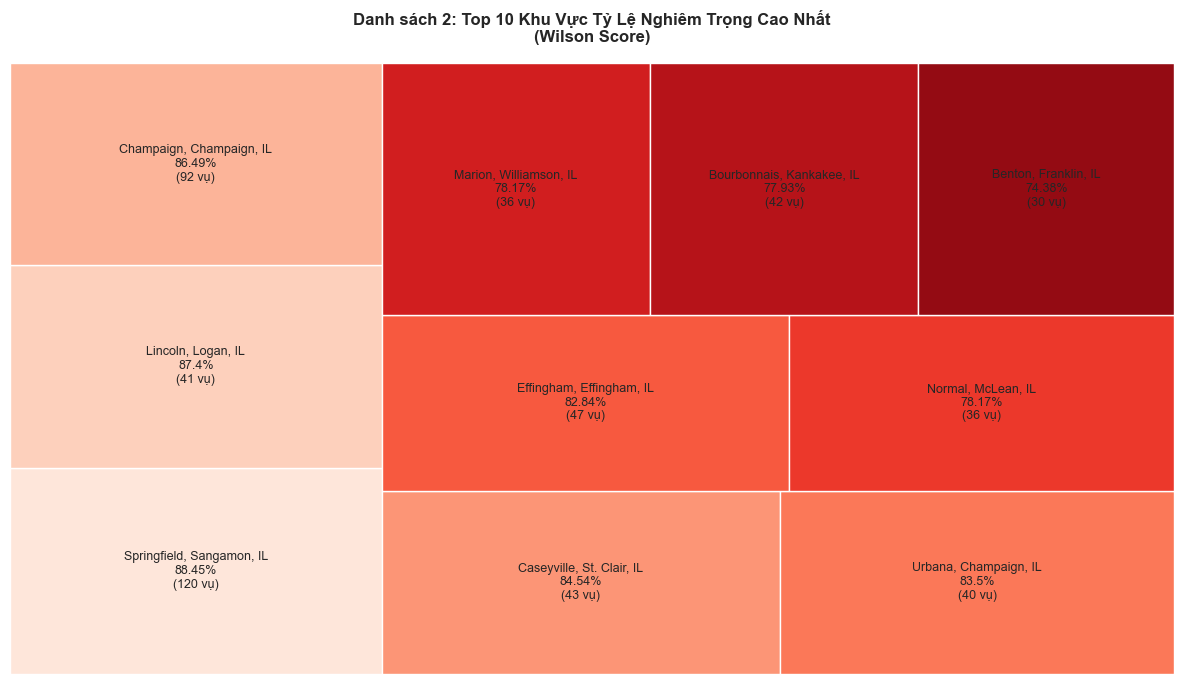

In [78]:
# 1. TẠO ĐỊNH DANH KHU VỰC: Ghép Thành phố, Hạt, Tiểu bang để tránh trùng lặp tên
df['Location_Key'] = df['City'].astype(str) + ', ' + df['County'].astype(str) + ', ' + df['State'].astype(str)

# 2. GOM NHÓM VÀ TÍNH TOÁN CÁC CHỈ SỐ CƠ BẢN
hotspot = df.groupby('Location_Key').agg(
    Total_Accidents=('ID', 'count'),                             # Đếm tổng số vụ
    Severe_Count=('Severity', lambda x: (x >= 3).sum()),         # Đếm số vụ Mức 3 và 4
    Weather_Related_Count=('Is_Adverse_Weather', 'sum'),         # Đếm số vụ do thời tiết
    Avg_Lat=('Start_Lat', 'mean'),                               # Tọa độ trung bình (Vĩ độ)
    Avg_Lng=('Start_Lng', 'mean')                                # Tọa độ trung bình (Kinh độ)
).reset_index()

# Tính tỷ lệ % thông thường
hotspot['Severe_Rate_%'] = (hotspot['Severe_Count'] / hotspot['Total_Accidents'] * 100).round(2)
hotspot['Weather_Related_Rate_%'] = (hotspot['Weather_Related_Count'] / hotspot['Total_Accidents'] * 100).round(2)

# 3. ÁP DỤNG THUẬT TOÁN WILSON SCORE
# Hàm tính mốc dưới của khoảng tin cậy Wilson để chuẩn hóa tỷ lệ dựa trên cỡ mẫu (n)
def wilson_lower_bound(pos, n, confidence=0.95):
    if n == 0:
        return 0
    z = sst.norm.ppf(1 - (1 - confidence) / 2) # Tính chỉ số Z-score (mặc định 95% tin cậy)
    phat = pos / n
    denom = 1 + z**2 / n
    centre = phat + z**2 / (2 * n)
    margin = z * np.sqrt((phat * (1 - phat) + z**2 / (4 * n)) / n)
    return (centre - margin) / denom

# Áp dụng hàm tính Wilson cho từng dòng dữ liệu để tạo cột tỷ lệ mới
hotspot['Wilson_Severe_Rate_%'] = hotspot.apply(
    lambda r: wilson_lower_bound(r['Severe_Count'], r['Total_Accidents']) * 100, axis=1
).round(2)


# ==========================================
# PHẦN 4: TRÍCH XUẤT VÀ VẼ BIỂU ĐỒ
# ==========================================

# --- DANH SÁCH 1: TOP THEO KHỐI LƯỢNG (VOLUME) ---
MIN_ACCIDENTS_VOLUME = 100 # Lọc bỏ các khu vực có dưới 100 vụ
list1_volume = hotspot[hotspot['Total_Accidents'] >= MIN_ACCIDENTS_VOLUME] \
    .sort_values('Total_Accidents', ascending=False).head(15)

print("=== DANH SÁCH 1: TOP HOTSPOT THEO KHỐI LƯỢNG ===")
print(list1_volume[['Location_Key','Total_Accidents','Severe_Rate_%','Weather_Related_Rate_%']].to_string(index=False))

# Trực quan hóa Danh sách 1 bằng Bar Chart
fig, ax = plt.subplots(figsize=(11, 6))
# Dùng dải màu Blues_r (Xanh đậm dần) để thể hiện số lượng
sns.barplot(data=list1_volume.head(10), x='Total_Accidents', y='Location_Key',
            hue='Location_Key', palette='Blues_r', legend=False, ax=ax)
ax.set_title('Danh sách 1: Top 10 Hotspot Theo Tổng Số Vụ (Khối Lượng)', fontweight='bold')
ax.set_xlabel('Tổng số vụ tai nạn')
ax.set_ylabel('Khu vực')
plt.tight_layout()
plt.show()


# --- DANH SÁCH 2: TOP THEO TỶ LỆ NGHIÊM TRỌNG (RATE) ---
MIN_ACCIDENTS_RATE = 30 # Đã dùng Wilson nên chỉ cần lọc nhẹ các khu vực có >= 30 vụ
list2_rate = hotspot[hotspot['Total_Accidents'] >= MIN_ACCIDENTS_RATE] \
    .sort_values('Wilson_Severe_Rate_%', ascending=False).head(15)

print("\n=== DANH SÁCH 2: TOP TỶ LỆ NGHIÊM TRỌNG (đã điều chỉnh cỡ mẫu) ===")
print(list2_rate[['Location_Key','Total_Accidents','Severe_Rate_%','Wilson_Severe_Rate_%']].to_string(index=False))

# Trực quan hóa Danh sách 2 bằng Treemap
top10_rate = list2_rate.head(10)
sizes = top10_rate['Wilson_Severe_Rate_%'].values

# Tạo nhãn hiển thị cho từng ô: Tên khu vực -> Tỷ lệ Wilson -> (Tổng số vụ)
labels = [f"{loc}\n{rate}%\n({n} vụ)" for loc, rate, n in
          zip(top10_rate['Location_Key'], top10_rate['Wilson_Severe_Rate_%'], top10_rate['Total_Accidents'])]

fig, ax = plt.subplots(figsize=(12, 7))
# Dùng dải màu Reds (Đỏ cảnh báo) để thể hiện sự nguy hiểm
squarify.plot(sizes=sizes, label=labels, ax=ax,
              color=sns.color_palette('Reds', len(sizes)), text_kwargs={'fontsize': 9})
ax.set_title('Danh sách 2: Top 10 Khu Vực Tỷ Lệ Nghiêm Trọng Cao Nhất\n(Wilson Score)', fontweight='bold', pad=15)
plt.axis('off') # Tắt trục tọa độ vì Treemap không cần
plt.tight_layout()
plt.show()

**Nhận xét:** Các siêu đô thị lớn như Miami (FL), Orlando (FL), Los Angeles (CA) và Houston (TX) dẫn đầu áp đảo về tổng số lượng vụ tai nạn. Tuy nhiên, tỷ lệ tai nạn nghiêm trọng (Mức 3 & 4) ở các khu vực này lại rất thấp (chỉ dao động ở mức 1% - 8%). Trong khi đó xếp hạng theo tỷ lệ nghiêm trọng thực chất (Wilson Score), toàn bộ Top 10 đều gọi tên các thành phố cỡ nhỏ và vừa thuộc **tiểu bang Illinois (IL)** như Springfield, Lincoln, Champaign hay Urbana. Mặc dù tổng số vụ tai nạn ở đây không cao (chỉ từ 40 - 120 vụ), nhưng tỷ lệ tai nạn đạt Mức 3 & 4 lên tới **hơn 80%**. 